# Update sesuain domain,  generic stopwords , Preprocess  dengan bertopic_new.ipynb

In [57]:
import pandas as pd
import random

SEED = 42
random.seed(SEED)

In [58]:
df_preprocessed = pd.read_csv(r"../preprocessed_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 35159


,full_text,image_url,created_at,tweet_url,id_str
0,saw guy coding today tab chatgpt gemini claude...,NaN,April 2025,https://x.com/Yuchenj_UW/status/19165377865194...,1916537786519425124
1,imagine way thinking edge taste strategy could...,https://pbs.twimg.com/amplify_video_thumb/1919...,May 2025,https://x.com/FractionAI_xyz/status/1919796178...,1919796178033483801
2,guy one kenya best brains know introducing joh...,https://pbs.twimg.com/media/G1wuNGRXAAE8RBi.jpg,September 2025,https://x.com/onjolo_kenya/status/197150154911...,1971501549110141021
3,know funny people hear pope leo xiv math degre...,https://pbs.twimg.com/media/GqyT_bsXQAAzDiI.jpg,May 2025,https://x.com/SecretFire79/status/192207386337...,1922073863376011765
4,people today discouraging others learning prog...,NaN,March 2025,https://x.com/AndrewYNg/status/190021911682210...,1900219116822102116


In [59]:
df_preprocessed.count()

full_text     35159
image_url     16102
created_at    35159
tweet_url     35159
id_str        35159
dtype: int64

In [60]:
# Semua kolom diambil dari df_preprocessed (sudah preprocessed) -> tidak ada preprocessing ulang.
docs = df_preprocessed['full_text'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
timestamps = df_preprocessed['created_at'].tolist()
ids = df_preprocessed['id_str'].tolist()
tweet_urls = df_preprocessed['tweet_url'].tolist()

for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli
# dan selaras dengan bertopic_new.ipynb (timestamps 1:1 dengan docs).
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: saw guy coding today tab chatgpt gemini claude grok deepseek asked every exact question patiently waited pasted response


In [61]:
# !pip install fastopic topmost sentence-transformers
!pip install --upgrade "nbformat>=4.2.0" plotly


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import numpy as np
import torch
from fastopic import FASTopic
from topmost import Preprocess

torch.cuda.empty_cache()
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe", "vibes"]
generic_stopwords = [
    "code", "coding"
]


preprocess =  Preprocess(
    stopwords=domain_stopwords + generic_stopwords,
)

## Evaluation: Coherence + Diversity Sweep

Untuk justifikasi pemilihan jumlah topik (K), kita sweep beberapa nilai K dan ukur tiga metric:

- **C_v coherence** — PMI berbasis sliding window + cosine similarity. Range ~0–1, semakin tinggi semakin koheren. Metric default di literatur BERTopic dan paling sering dilaporkan.
- **C_npmi (Normalized PMI)** — Versi normalisasi dari pointwise mutual information. Range ~[-1, 1] tapi praktis di tweet biasanya 0.05–0.20. Lebih sensitif terhadap rare co-occurrence dan dipakai sebagai metric utama di paper FASTopic & ECRTM.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0–1, semakin tinggi berarti topik semakin berbeda satu sama lain.

Trade-off: coherence tinggi sering datang bersama diversity rendah (topik mirip-mirip). Combined score `((c_v + (c_npmi+1)/2) / 2) * diversity` dipakai sebagai heuristik default — `(c_npmi+1)/2` untuk normalisasi ke skala 0–1 sebelum dirata-rata dengan c_v.

In [63]:
from topmost.eva import _coherence, _diversity

# Pre-compute reference corpus & vocab dari preprocess yang sama -> konsisten antar K dan antar model.
prep_result = preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    - c_v: PMI berbasis sliding window + cosine. Range ~0–1, populer di literatur BERTopic.
    - c_npmi: Normalized PMI. Range ~[-1, 1]. Lebih sensitif terhadap rare co-occurrence,
      sering dipakai di paper FASTopic & ECRTM. Nilai ~0.05–0.20 biasa untuk tweet.
    - diversity: proporsi kata unik di seluruh top words. Range 0–1.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}

parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 47873.16it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-06-23 23:00:40,727 - TopMost - Real vocab size: 28664
2026-06-23 23:00:40,732 - TopMost - Real training size: 35159 	 avg length: 16.129


Reference corpus: 35159 docs | vocab: 28664 terms


In [64]:
# K-sweep: latih FASTopic untuk beberapa nilai K dan ukur metric.
# Tiap fit ~25 detik di GPU, total ~2 menit untuk 5 nilai.
import random as _random
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training FASTopic with K={k} ===")
    _random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    m = FASTopic(
        num_topics=k,
        preprocess=preprocess,
        doc_embed_model="sentence-transformers/all-MiniLM-L6-v2",
        num_top_words=15,
        device="cuda",
        verbose=False,
        low_memory=True,
        low_memory_batch_size=3000
    )
    tw, _ = m.fit_transform(docs)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K'] = k
    sweep_results.append(metrics)
    print(f"  K={k}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")

sweep_df = pd.DataFrame(sweep_results)[['K', 'c_v', 'c_npmi', 'diversity']]
# Combined score: rata-rata coherence (c_v + c_npmi normalisasi sederhana) dikali diversity.
# c_npmi bisa negatif jadi kita pakai (c_npmi + 1)/2 supaya skala 0-1 sebelum dirata-rata dengan c_v.
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training FASTopic with K=8 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12852.57it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 49284.23it/s]
2026-06-23 23:00:51,270 - TopMost - Real vocab size: 28664
2026-06-23 23:00:51,274 - TopMost - Real training size: 35159 	 avg length: 16.129
Training FASTopic: 100%|██████████| 200/200 [13:39<00:00,  4.10s/it]


  K=8  c_v=0.4590  c_npmi=-0.1649  diversity=0.6250

=== Training FASTopic with K=12 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10185.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 41667.11it/s]
2026-06-23 23:15:40,303 - TopMost - Real vocab size: 28664
2026-06-23 23:15:40,306 - TopMost - Real training size: 35159 	 avg length: 16.129
Training FASTopic: 100%|██████████| 200/200 [13:34<00:00,  4.07s/it]


  K=12  c_v=0.4162  c_npmi=-0.1670  diversity=0.4917

=== Training FASTopic with K=15 ===


...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8528.54it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 51907.08it/s]
2026-06-23 23:43:54,486 - TopMost - Real vocab size: 28664
2026-06-23 23:43:54,486 - TopMost - Real training size: 35159 	 avg length: 16.129
Training FASTopic: 100%|██████████| 200/200 [10:37<00:00,  3.19s/it]


  K=20  c_v=0.4388  c_npmi=-0.1885  diversity=0.4850

=== Training FASTopic with K=25 ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6256.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 51250.65it/s]
2026-06-23 23:55:25,760 - TopMost - Real vocab size: 28664
2026-06-23 23:55:25,760 - TopMost - Real training size: 35159 	 avg length: 16.129
Training FASTopic: 100%|██████████| 200/200 [10:35<00:00,  3.18s/it]


  K=25  c_v=0.4710  c_npmi=-0.1706  diversity=0.4360


,K,c_v,c_npmi,diversity,combined
0,8,0.458963,-0.164859,0.625000,0.273917
2,15,0.425673,-0.097141,0.593333,0.260207
3,20,0.438816,-0.188507,0.485000,0.204806
1,12,0.416194,-0.166982,0.491667,0.204706
4,25,0.471026,-0.170571,0.436000,0.193091


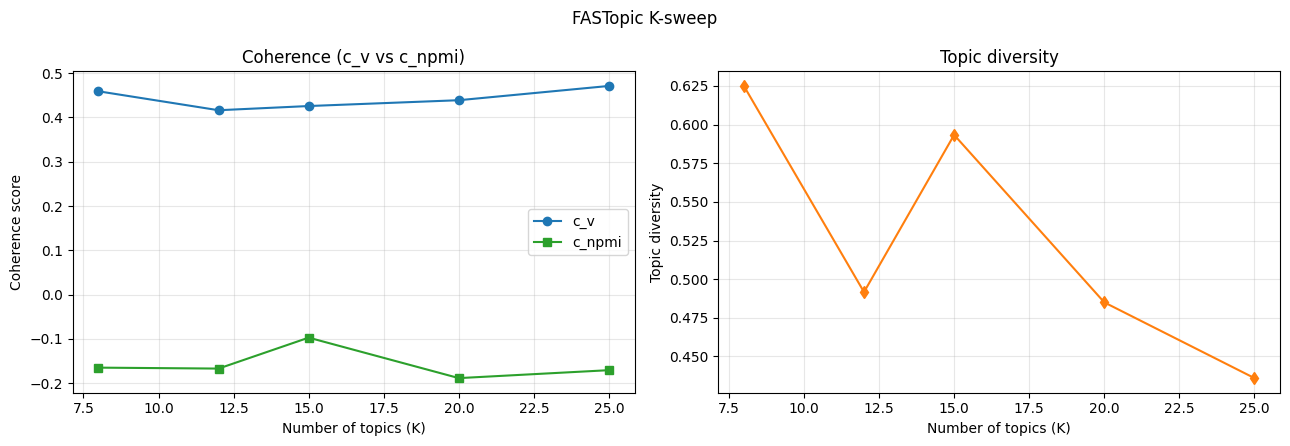


Rekomendasi K (max combined score): 8
Cell training di bawah otomatis pakai best_k. Override manual jika perlu.


In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Kiri: dua coherence metric
ax1 = axes[0]
ax1.plot(sweep_df['K'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (K)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

# Kanan: diversity
ax2 = axes[1]
ax2.plot(sweep_df['K'], sweep_df['diversity'], 'd-', color='tab:orange', label='diversity')
ax2.set_xlabel('Number of topics (K)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('FASTopic K-sweep')
fig.tight_layout()
plt.show()

# Pilih K dengan kombinasi terbaik. Override manual jika domain knowledge bilang lain.
best_k = int(sweep_df.loc[sweep_df['combined'].idxmax(), 'K'])
print(f"\nRekomendasi K (max combined score): {best_k}")
print("Cell training di bawah otomatis pakai best_k. Override manual jika perlu.")

In [66]:
import random as _random
# Training final dengan K hasil sweep. Override manual jika ingin nilai lain (mis. NUM_TOPICS = 15).
NUM_TOPICS = best_k

_random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = FASTopic(
    num_topics=NUM_TOPICS,
    preprocess=preprocess,
    doc_embed_model="sentence-transformers/all-MiniLM-L6-v2",
    num_top_words=15,
    device="cuda",      # ganti ke "cpu" jika tidak ada GPU
    verbose=True,
    low_memory=True,
    low_memory_batch_size=3000  
)

top_words, doc_topic_dist = model.fit_transform(docs)

# Cetak metric final
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal model | K={NUM_TOPICS}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

# Simpan untuk perbandingan lintas model
fastopic_metrics = {**final_metrics, 'model': 'FASTopic', 'K': NUM_TOPICS}

2026-06-24 00:06:44,231 - FASTopic - use device: cuda
2026-06-24 00:06:44,231 - FASTopic - Using low memory mode.
2026-06-24 00:06:44,231 - FASTopic - First fit the model.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 51436.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 35159/35159 [00:00<00:00, 52313.77it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-06-24 00:06:53,162 - TopMost - Real vocab size: 28664
2026-06-24 00:06:53,162 - TopMost - Real training size: 35159 	 avg length: 16.12

Topic 0: books listening ebook rubin lmao rage soul macbook rick book nerds wtf american war steve
Topic 1: fuck hate bad slop fucking error rule worse keyboard kernel hell vibing rust shit opposite
Topic 2: books listening ebook rubin lmao rage soul macbook rick book nerds wtf american war music
Topic 3: like build new one tools app using building time use people get claude apps llm
Topic 4: agents data platform powered decentralized defi agent chain blockchain intelligence web models future earn crypto
Topic 5: books listening ebook rubin lmao rage soul macbook rick book nerds wtf american war music
Topic 6: day week live year today join days market community tech last share launch next saas
Topic 7: books listening ebook rubin lmao rage soul macbook rick book nerds wtf american war music

Final model | K=8  c_v=0.4590  c_npmi=-0.1649  diversity=0.6250

Topic 0: books listening ebook rubin lmao rage soul macbook rick book nerds wtf american war steve
Topic 1: fuck hate bad slop fucki

In [67]:
import numpy as np

doc_topics = doc_topic_dist.argmax(axis=1)
sizes = (
    pd.Series(doc_topics)
    .value_counts()
    .reindex(range(len(top_words)), fill_value=0)
    .values
)

topic_info = pd.DataFrame({
    "topic_id": range(len(top_words)),
    "size": sizes,
    "top_words": top_words,
})
topic_info.sort_values("size", ascending=False).head(30)

,topic_id,size,top_words
4,4,9265,agents data platform powered decentralized def...
1,1,8658,fuck hate bad slop fucking error rule worse ke...
6,6,6967,day week live year today join days market comm...
3,3,3524,like build new one tools app using building ti...
0,0,2354,books listening ebook rubin lmao rage soul mac...
2,2,2097,books listening ebook rubin lmao rage soul mac...
5,5,1543,books listening ebook rubin lmao rage soul mac...
7,7,751,books listening ebook rubin lmao rage soul mac...


In [68]:
# Top words per topic with weights
fig = model.visualize_topic(top_n=8)
fig.show()

In [69]:
# Topic prevalence across the corpus
fig = model.visualize_topic_weights(top_n=30, height=600)
fig.show()

In [70]:
# Hierarchical view of topics
fig = model.visualize_topic_hierarchy()
fig.show()

c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\fastopic\_plot.py:265: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_function = lambda x: sch.linkage(x, 'ward', optimal_ordering=True)


In [71]:
# Inspect example tweets per topic
def sample_docs_for_topic(topic_id, n=5):
    idx = np.where(doc_topics == topic_id)[0]
    if len(idx) == 0:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

for tid in topic_info.sort_values("size", ascending=False)["topic_id"].head(10):
    print(f"\n=== Topic {tid} | {' | '.join(top_words[tid].split()[:10])} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 4 | agents | data | platform | powered | decentralized | defi | agent | chain | blockchain | intelligence ===
 - thinking wild literally bet trading strategies coding stress pure alpha feels like watching future unfold real time deai done right still anticipating launch
 - coding without systems thinking tech debt speedrun delty staff engineer team deep expertise designs software evaluates tradeoffs makes agents smarter engineering context
 - still billion dollar app build cursor solidity coding sidekick deal copilot devs guiding secure contract creation deployments imagine web development

=== Topic 1 | fuck | hate | bad | slop | fucking | error | rule | worse | keyboard | kernel ===
 - script sorcerer surge nov pairs grok fast code god tier coding reasoning leaps squash errors tangled scripts data dive prompt upgrades track webs like pros morphing unbreakable build buddy iterates in
 - give shit coding tool using neither care learning habits mean pick future
 - see people 

In [72]:
# Save the trained model + assignments
import os, pickle

os.makedirs("artifacts", exist_ok=True)
model.save("artifacts/fastopic_vibecoding")

assignments = pd.DataFrame({
    "doc": docs,
    "topic_id": doc_topics,
    "topic_prob": doc_topic_dist.max(axis=1),
})
assignments.to_csv("artifacts/fastopic_assignments.csv", index=False)
topic_info.to_csv("artifacts/fastopic_topic_info.csv", index=False)

## Topic over Time

Memvisualisasikan aktivitas topik sepanjang waktu memakai kolom `created_at` yang **sudah
tersedia di `preprocessed_tweets.csv`** (granularitas bulanan, mis. "April 2025"). Sama seperti
`bertopic_new.ipynb`, timestamp diambil langsung dari `df_preprocessed` — **tidak ada
rekonstruksi atau preprocessing ulang** dari raw source.

Karena `docs` **tidak di-shuffle** (lihat cell prep di atas, selaras dengan bertopic_new),
`timestamps` selaras 1:1 per-posisi dengan urutan `docs` saat fit.

FASTopic `topic_activity_over_time(time_slices)` meng-aggregate transport-plan dokumen->topik
per label periode, di mana `time_slices` adalah label periode **per-dokumen** (panjang = jumlah docs).

In [73]:
# created_at sudah tersedia & sudah preprocessed di df_preprocessed -> TIDAK perlu rekonstruksi
# atau preprocessing ulang dari raw source (sama seperti bertopic_new.ipynb yang langsung pakai
# timestamps). Karena docs TIDAK di-shuffle, timestamps selaras 1:1 dengan urutan docs saat fit.
doc_time = pd.to_datetime(pd.Series(timestamps))
assert len(doc_time) == len(docs)
print(f"Aligned {len(doc_time)} timestamps ke urutan docs | {doc_time.min()} -> {doc_time.max()}")

Aligned 35159 timestamps ke urutan docs | 2025-02-01 00:00:00 -> 2026-02-01 00:00:00


C:\Users\Allen\AppData\Local\Temp\ipykernel_16012\2211005757.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  doc_time = pd.to_datetime(pd.Series(timestamps))


In [74]:
# time_slices: label periode (bulanan) per-dokumen, selaras dgn urutan docs saat fit.
# Format 'YYYY-MM' supaya label terurut kronologis di sumbu-x.
time_slices = doc_time.dt.to_period("M").astype(str).tolist()
assert len(time_slices) == len(docs)

# CATATAN: topic_activity_over_time memodifikasi transp_DT in-place (mengalikan dgn N).
# Jalankan cell ini SEKALI per fit; bila perlu mengulang, re-run cell training model dulu.
act = model.topic_activity_over_time(time_slices)
fig = model.visualize_topic_activity(top_n=6, topic_activity=act, time_slices=time_slices)

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()